# 第二十九章：Stable Diffusion (Latent Diffusion Model) 關鍵組件實作

本 notebook 實作 Latent Diffusion Model 的核心組件，包括：
1. VAE 編碼器和解碼器（感知壓縮）
2. 跨注意力機制（Cross-Attention）
3. 潛在空間中的 U-Net
4. Classifier-Free Guidance
5. 各種採樣方法

**注意**：完整的 Stable Diffusion 實作請參考 HuggingFace Diffusers 函式庫。

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch 版本: {torch.__version__}")

PyTorch 版本: 2.9.0+cu126


## 1. VAE 編碼器

VAE 編碼器將圖像壓縮到低維潛在空間。

In [7]:
class ResBlock(nn.Module):
    """殘差塊，用於編碼器和解碼器"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        
    def forward(self, x):
        h = self.conv1(F.silu(self.norm1(x)))
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.shortcut(x)


class AttnBlock(nn.Module):
    """自注意力塊"""
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(32, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)
        
    def forward(self, x):
        b, c, h, w = x.shape
        
        x_norm = self.norm(x)
        qkv = self.qkv(x_norm).reshape(b, 3, c, h * w)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        
        # 計算注意力
        attn = torch.softmax(q.transpose(-1, -2) @ k / (c ** 0.5), dim=-1)
        out = (v @ attn.transpose(-1, -2)).reshape(b, c, h, w)
        
        return x + self.proj(out)


class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
        
    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)
        
    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)


class VAEEncoder(nn.Module):
    """
    VAE 編碼器：圖像 → 潛在分布參數
    
    輸入：[B, 3, 256, 256]
    輸出：[B, 8, 32, 32] (mean 和 log_var 合併)
    """
    def __init__(self, ch=128, ch_mult=(1, 2, 4, 4), z_ch=4):
        super().__init__()
        
        # 初始卷積
        self.conv_in = nn.Conv2d(3, ch, 3, padding=1)
        
        # 下採樣塊
        self.down_blocks = nn.ModuleList()
        curr_ch = ch
        for i, mult in enumerate(ch_mult):
            out_ch = ch * mult
            # 兩個殘差塊
            self.down_blocks.append(ResBlock(curr_ch, out_ch))
            self.down_blocks.append(ResBlock(out_ch, out_ch))
            curr_ch = out_ch
            # 下採樣（除了最後一層）
            if i < len(ch_mult) - 1:
                self.down_blocks.append(Downsample(curr_ch))
        
        # 中間層
        self.mid = nn.Sequential(
            ResBlock(curr_ch, curr_ch),
            AttnBlock(curr_ch),
            ResBlock(curr_ch, curr_ch)
        )
        
        # 輸出
        self.norm_out = nn.GroupNorm(32, curr_ch)
        self.conv_out = nn.Conv2d(curr_ch, 2 * z_ch, 3, padding=1)  # mean 和 log_var
        
    def forward(self, x):
        h = self.conv_in(x)
        
        for block in self.down_blocks:
            h = block(h)
        
        h = self.mid(h)
        h = self.conv_out(F.silu(self.norm_out(h)))
        
        return h

# 測試編碼器
encoder = VAEEncoder(ch=64, ch_mult=(1, 2, 4), z_ch=4)
x = torch.randn(2, 3, 64, 64)
z_params = encoder(x)
print(f"輸入形狀: {x.shape}")
print(f"潛在參數形狀: {z_params.shape}")

# 分離 mean 和 log_var
z_ch = z_params.shape[1] // 2
mean, log_var = z_params[:, :z_ch], z_params[:, z_ch:]
print(f"Mean 形狀: {mean.shape}")
print(f"Log Var 形狀: {log_var.shape}")

輸入形狀: torch.Size([2, 3, 64, 64])
潛在參數形狀: torch.Size([2, 8, 16, 16])
Mean 形狀: torch.Size([2, 4, 16, 16])
Log Var 形狀: torch.Size([2, 4, 16, 16])


## 2. VAE 解碼器

VAE 解碼器將潛在表示還原為圖像。

In [8]:
class VAEDecoder(nn.Module):
    """
    VAE 解碼器：潛在表示 → 圖像
    
    輸入：[B, 4, 32, 32]
    輸出：[B, 3, 256, 256]
    """
    def __init__(self, ch=128, ch_mult=(1, 2, 4, 4), z_ch=4):
        super().__init__()
        
        # 計算初始通道數
        curr_ch = ch * ch_mult[-1]
        
        # 輸入投影
        self.conv_in = nn.Conv2d(z_ch, curr_ch, 3, padding=1)
        
        # 中間層
        self.mid = nn.Sequential(
            ResBlock(curr_ch, curr_ch),
            AttnBlock(curr_ch),
            ResBlock(curr_ch, curr_ch)
        )
        
        # 上採樣塊
        self.up_blocks = nn.ModuleList()
        for i, mult in enumerate(reversed(ch_mult)):
            out_ch = ch * mult
            # 三個殘差塊
            for j in range(3):
                self.up_blocks.append(ResBlock(curr_ch, out_ch))
                curr_ch = out_ch
            # 上採樣（除了最後一層）
            if i < len(ch_mult) - 1:
                self.up_blocks.append(Upsample(curr_ch))
        
        # 輸出
        self.norm_out = nn.GroupNorm(32, curr_ch)
        self.conv_out = nn.Conv2d(curr_ch, 3, 3, padding=1)
        
    def forward(self, z):
        h = self.conv_in(z)
        h = self.mid(h)
        
        for block in self.up_blocks:
            h = block(h)
        
        h = self.conv_out(F.silu(self.norm_out(h)))
        return h

# 測試解碼器
decoder = VAEDecoder(ch=64, ch_mult=(1, 2, 4), z_ch=4)
z = torch.randn(2, 4, 8, 8)
x_recon = decoder(z)
print(f"潛在輸入形狀: {z.shape}")
print(f"重建圖像形狀: {x_recon.shape}")

潛在輸入形狀: torch.Size([2, 4, 8, 8])
重建圖像形狀: torch.Size([2, 3, 32, 32])


## 3. 完整的 VAE

組合編碼器和解碼器，加入重參數化技巧。

In [9]:
class VAE(nn.Module):
    """
    完整的 VAE 模型
    
    用於 Latent Diffusion 的感知壓縮階段
    """
    def __init__(self, ch=128, ch_mult=(1, 2, 4, 4), z_ch=4):
        super().__init__()
        self.encoder = VAEEncoder(ch, ch_mult, z_ch)
        self.decoder = VAEDecoder(ch, ch_mult, z_ch)
        self.z_ch = z_ch
        
    def encode(self, x):
        """編碼為潛在分布參數"""
        h = self.encoder(x)
        mean, log_var = h[:, :self.z_ch], h[:, self.z_ch:]
        return mean, log_var
    
    def reparameterize(self, mean, log_var):
        """重參數化技巧"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mean + eps * std
    
    def decode(self, z):
        """解碼"""
        return self.decoder(z)
    
    def forward(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        x_recon = self.decode(z)
        return x_recon, mean, log_var
    
    def compute_loss(self, x):
        """
        計算 VAE 損失
        
        包含重建損失和 KL 散度
        """
        x_recon, mean, log_var = self.forward(x)
        
        # 重建損失
        recon_loss = F.mse_loss(x_recon, x, reduction='mean')
        
        # KL 散度
        kl_loss = -0.5 * torch.mean(1 + log_var - mean.pow(2) - log_var.exp())
        
        return recon_loss, kl_loss

# 測試 VAE
vae = VAE(ch=64, ch_mult=(1, 2, 4), z_ch=4)
x = torch.randn(2, 3, 64, 64)

recon_loss, kl_loss = vae.compute_loss(x)
print(f"重建損失: {recon_loss.item():.4f}")
print(f"KL 損失: {kl_loss.item():.4f}")

重建損失: 1.1334
KL 損失: 0.0842


## 4. 跨注意力機制（Cross-Attention）

跨注意力是 Stable Diffusion 實現條件生成的關鍵。

In [10]:
class CrossAttention(nn.Module):
    """
    跨注意力層
    
    讓圖像特徵能夠注意到文字條件
    Q 來自圖像特徵，K 和 V 來自文字嵌入
    """
    def __init__(self, query_dim, context_dim=None, heads=8, dim_head=64, dropout=0.0):
        super().__init__()
        context_dim = context_dim or query_dim
        inner_dim = heads * dim_head
        
        self.heads = heads
        self.scale = dim_head ** -0.5
        
        self.to_q = nn.Linear(query_dim, inner_dim, bias=False)
        self.to_k = nn.Linear(context_dim, inner_dim, bias=False)
        self.to_v = nn.Linear(context_dim, inner_dim, bias=False)
        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, query_dim),
            nn.Dropout(dropout)
        )
        
    def forward(self, x, context=None):
        """
        Args:
            x: [B, N, C] 圖像特徵（N = H*W）
            context: [B, L, D] 條件嵌入（L = 文字長度）
                     如果為 None，則做自注意力
        """
        if context is None:
            context = x  # 自注意力

        b, n, _ = x.shape
        h = self.heads

        # 計算 Q, K, V
        q = self.to_q(x)  # [B, N, inner_dim]
        k = self.to_k(context)
        v = self.to_v(context)

        # 取得 context 的序列長度和計算 dim_head
        context_len = context.shape[1]
        dim_head = q.shape[-1] // h

        # 重塑為多頭（不能使用兩個 -1，必須明確指定維度）
        q = q.view(b, n, h, dim_head).transpose(1, 2)  # [B, h, N, dim_head]
        k = k.view(b, context_len, h, dim_head).transpose(1, 2)  # [B, h, L, dim_head]
        v = v.view(b, context_len, h, dim_head).transpose(1, 2)
        
        # 計算注意力
        attn = (q @ k.transpose(-2, -1)) * self.scale  # [B, h, N, L]
        attn = attn.softmax(dim=-1)
        
        # 應用注意力
        out = (attn @ v).transpose(1, 2).reshape(b, n, -1)  # [B, N, inner_dim]
        return self.to_out(out)


class BasicTransformerBlock(nn.Module):
    """
    Transformer 塊：自注意力 + 跨注意力 + FFN
    
    這是 Stable Diffusion U-Net 中使用的基本單元
    """
    def __init__(self, dim, num_heads=8, dim_head=64, context_dim=768, dropout=0.0):
        super().__init__()
        
        # 自注意力
        self.norm1 = nn.LayerNorm(dim)
        self.attn1 = CrossAttention(dim, dim, num_heads, dim_head, dropout)
        
        # 跨注意力（條件）
        self.norm2 = nn.LayerNorm(dim)
        self.attn2 = CrossAttention(dim, context_dim, num_heads, dim_head, dropout)
        
        # FFN
        self.norm3 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim),
            nn.Dropout(dropout)
        )
        
    def forward(self, x, context=None):
        """
        Args:
            x: [B, N, C] 圖像特徵
            context: [B, L, D] 文字嵌入
        """
        # 自注意力
        x = x + self.attn1(self.norm1(x))
        # 跨注意力
        x = x + self.attn2(self.norm2(x), context)
        # FFN
        x = x + self.ff(self.norm3(x))
        return x

# 測試
block = BasicTransformerBlock(dim=256, context_dim=768)
image_feat = torch.randn(2, 64, 256)  # [B, H*W, C]
text_emb = torch.randn(2, 77, 768)     # [B, L, D] (CLIP 輸出)

output = block(image_feat, text_emb)
print(f"圖像特徵形狀: {image_feat.shape}")
print(f"文字嵌入形狀: {text_emb.shape}")
print(f"輸出形狀: {output.shape}")

圖像特徵形狀: torch.Size([2, 64, 256])
文字嵌入形狀: torch.Size([2, 77, 768])
輸出形狀: torch.Size([2, 64, 256])


## 5. 時間嵌入

使用正弦位置編碼表示擴散時間步。

In [11]:
class TimeEmbedding(nn.Module):
    """
    時間步嵌入
    
    使用正弦位置編碼 + MLP
    """
    def __init__(self, dim, max_period=10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period
        
        # MLP
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim * 4)
        )
        
    def forward(self, t):
        """
        Args:
            t: [B] 時間步（0 到 1000）
        Returns:
            [B, dim * 4] 時間嵌入
        """
        half_dim = self.dim // 2
        freqs = torch.exp(
            -np.log(self.max_period) * torch.arange(half_dim, device=t.device) / half_dim
        )
        args = t[:, None] * freqs[None, :]
        embedding = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        
        return self.mlp(embedding)

# 測試
time_embed = TimeEmbedding(dim=256)
t = torch.tensor([100, 500, 900], dtype=torch.float32)
t_emb = time_embed(t)
print(f"時間步: {t.tolist()}")
print(f"時間嵌入形狀: {t_emb.shape}")

時間步: [100.0, 500.0, 900.0]
時間嵌入形狀: torch.Size([3, 1024])


## 6. Classifier-Free Guidance

CFG 是增強條件影響力的重要技術。

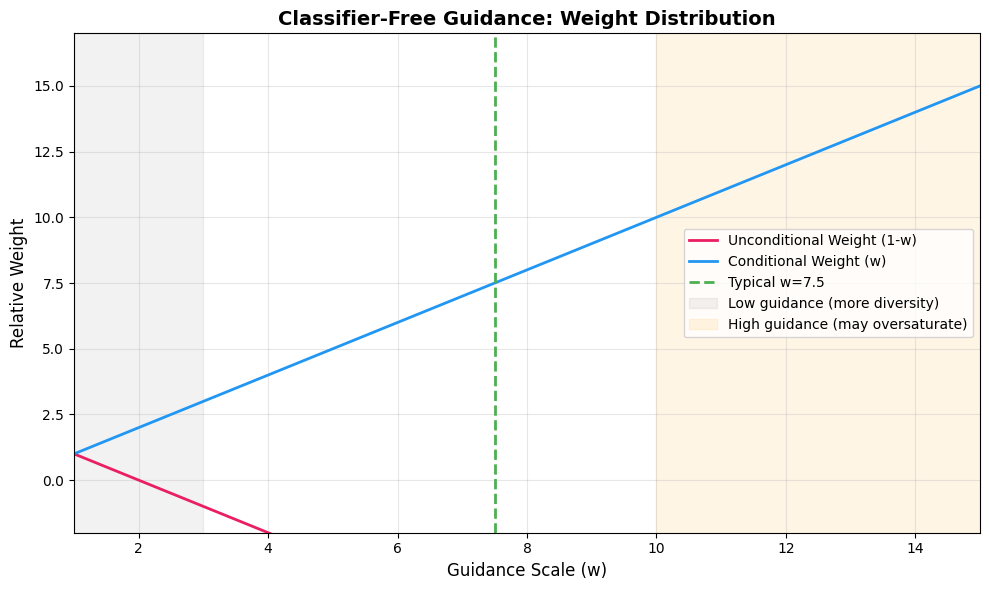


圖片已儲存為 cfg_visualization.png


In [12]:
def classifier_free_guidance(
    model,
    z_t: torch.Tensor,
    t: torch.Tensor,
    context: torch.Tensor,
    null_context: torch.Tensor,
    guidance_scale: float = 7.5
) -> torch.Tensor:
    """
    Classifier-Free Guidance
    
    結合有條件和無條件的預測：
    ε_guided = ε_uncond + w * (ε_cond - ε_uncond)
    
    Args:
        model: U-Net 模型
        z_t: 當前噪音潛在表示
        t: 時間步
        context: 條件嵌入（文字）
        null_context: 空條件嵌入
        guidance_scale: 引導強度 w
        
    Returns:
        引導後的噪音預測
    """
    # 無條件預測
    noise_uncond = model(z_t, t, null_context)
    
    # 有條件預測
    noise_cond = model(z_t, t, context)
    
    # 引導
    noise_guided = noise_uncond + guidance_scale * (noise_cond - noise_uncond)
    
    return noise_guided

# 視覺化 CFG 效果
import matplotlib.pyplot as plt

# 模擬不同引導強度的效果
guidance_scales = np.linspace(1, 15, 100)
uncond_weight = 1 - guidance_scales + 1  # 相對權重
cond_weight = guidance_scales

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(guidance_scales, uncond_weight, label='Unconditional Weight (1-w)', color='#E91E63', linewidth=2)
ax.plot(guidance_scales, cond_weight, label='Conditional Weight (w)', color='#2196F3', linewidth=2)
ax.axvline(x=7.5, color='#4CAF50', linestyle='--', linewidth=2, label='Typical w=7.5')
ax.fill_between([1, 3], -2, 17, alpha=0.1, color='gray', label='Low guidance (more diversity)')
ax.fill_between([10, 15], -2, 17, alpha=0.1, color='orange', label='High guidance (may oversaturate)')

ax.set_xlabel('Guidance Scale (w)', fontsize=12)
ax.set_ylabel('Relative Weight', fontsize=12)
ax.set_title('Classifier-Free Guidance: Weight Distribution', fontsize=14, fontweight='bold')
ax.legend(loc='center right', fontsize=10)
ax.set_xlim(1, 15)
ax.set_ylim(-2, 17)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cfg_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n圖片已儲存為 cfg_visualization.png")

## 7. 採樣方法

實作 DDPM 和 DDIM 採樣。

In [13]:
class NoiseScheduler:
    """
    噪音調度器
    
    管理擴散過程中的 beta 和 alpha 值
    """
    def __init__(self, num_steps=1000, beta_start=0.0001, beta_end=0.02):
        self.num_steps = num_steps
        
        # 線性 beta 調度
        self.betas = torch.linspace(beta_start, beta_end, num_steps)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        
    def add_noise(self, x_0, t, noise=None):
        """前向過程：加噪"""
        if noise is None:
            noise = torch.randn_like(x_0)
        
        alpha_bar_t = self.alpha_bars[t].view(-1, 1, 1, 1).to(x_0.device)
        
        # q(x_t | x_0)
        x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * noise
        return x_t, noise
    
    def ddpm_step(self, x_t, t, noise_pred):
        """DDPM 採樣步驟"""
        alpha_t = self.alphas[t].view(-1, 1, 1, 1).to(x_t.device)
        alpha_bar_t = self.alpha_bars[t].view(-1, 1, 1, 1).to(x_t.device)
        beta_t = self.betas[t].view(-1, 1, 1, 1).to(x_t.device)
        
        # 預測 x_0
        x_0_pred = (x_t - torch.sqrt(1 - alpha_bar_t) * noise_pred) / torch.sqrt(alpha_bar_t)
        
        # 計算均值
        if t[0] > 0:
            alpha_bar_t_prev = self.alpha_bars[t - 1].view(-1, 1, 1, 1).to(x_t.device)
            mean = (torch.sqrt(alpha_bar_t_prev) * beta_t / (1 - alpha_bar_t) * x_0_pred +
                   torch.sqrt(alpha_t) * (1 - alpha_bar_t_prev) / (1 - alpha_bar_t) * x_t)
            var = beta_t * (1 - alpha_bar_t_prev) / (1 - alpha_bar_t)
            noise = torch.randn_like(x_t)
            x_t_prev = mean + torch.sqrt(var) * noise
        else:
            x_t_prev = x_0_pred
            
        return x_t_prev
    
    def ddim_step(self, x_t, t, t_prev, noise_pred, eta=0.0):
        """
        DDIM 採樣步驟
        
        eta=0 給出確定性採樣
        eta=1 等同於 DDPM
        """
        alpha_bar_t = self.alpha_bars[t].view(-1, 1, 1, 1).to(x_t.device)
        alpha_bar_t_prev = self.alpha_bars[t_prev].view(-1, 1, 1, 1).to(x_t.device) if t_prev >= 0 else torch.ones_like(alpha_bar_t)
        
        # 預測 x_0
        x_0_pred = (x_t - torch.sqrt(1 - alpha_bar_t) * noise_pred) / torch.sqrt(alpha_bar_t)
        
        # 計算方差
        sigma_t = eta * torch.sqrt((1 - alpha_bar_t_prev) / (1 - alpha_bar_t)) * torch.sqrt(1 - alpha_bar_t / alpha_bar_t_prev)
        
        # 計算 x_{t-1}
        dir_xt = torch.sqrt(1 - alpha_bar_t_prev - sigma_t ** 2) * noise_pred
        x_t_prev = torch.sqrt(alpha_bar_t_prev) * x_0_pred + dir_xt
        
        if eta > 0:
            noise = torch.randn_like(x_t)
            x_t_prev = x_t_prev + sigma_t * noise
            
        return x_t_prev

# 測試
scheduler = NoiseScheduler(num_steps=1000)

# 測試前向過程
x_0 = torch.randn(2, 4, 8, 8)
t = torch.tensor([100, 500])
x_t, noise = scheduler.add_noise(x_0, t)
print(f"原始潛在形狀: {x_0.shape}")
print(f"加噪後形狀: {x_t.shape}")
print(f"\nAlpha bar at t=100: {scheduler.alpha_bars[100]:.4f}")
print(f"Alpha bar at t=500: {scheduler.alpha_bars[500]:.4f}")
print(f"Alpha bar at t=900: {scheduler.alpha_bars[900]:.4f}")

原始潛在形狀: torch.Size([2, 4, 8, 8])
加噪後形狀: torch.Size([2, 4, 8, 8])

Alpha bar at t=100: 0.8951
Alpha bar at t=500: 0.0778
Alpha bar at t=900: 0.0003


## 8. 完整的採樣循環

In [14]:
class SimpleDiffusionModel(nn.Module):
    """簡化的擴散模型（用於示範採樣流程）"""
    def __init__(self, channels=4, dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, dim, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(dim, dim, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(dim, channels, 3, padding=1)
        )
        self.time_mlp = nn.Sequential(
            nn.Linear(128, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )
        
    def forward(self, x, t, context=None):
        # 簡化：只用時間調制
        return self.net(x)


@torch.no_grad()
def sample_ddpm(
    model,
    scheduler,
    shape,
    context=None,
    guidance_scale=7.5,
    device='cpu'
):
    """
    DDPM 採樣
    
    Args:
        model: 擴散模型
        scheduler: 噪音調度器
        shape: 輸出形狀 [B, C, H, W]
        context: 條件嵌入
        guidance_scale: CFG 引導強度
    """
    batch_size = shape[0]
    
    # 初始化隨機噪音
    x = torch.randn(shape, device=device)
    
    # 迭代去噪
    for t in reversed(range(scheduler.num_steps)):
        t_tensor = torch.tensor([t] * batch_size, device=device)
        
        # 預測噪音
        noise_pred = model(x, t_tensor, context)
        
        # DDPM 步驟
        x = scheduler.ddpm_step(x, t_tensor, noise_pred)
        
    return x


@torch.no_grad()
def sample_ddim(
    model,
    scheduler,
    shape,
    num_inference_steps=50,
    context=None,
    guidance_scale=7.5,
    eta=0.0,
    device='cpu'
):
    """
    DDIM 採樣
    
    使用更少的步驟進行採樣
    """
    batch_size = shape[0]
    
    # 創建時間步子集
    step_ratio = scheduler.num_steps // num_inference_steps
    timesteps = list(range(0, scheduler.num_steps, step_ratio))[::-1]
    
    # 初始化
    x = torch.randn(shape, device=device)
    
    # 迭代去噪
    for i, t in enumerate(timesteps):
        t_tensor = torch.tensor([t] * batch_size, device=device)
        t_prev = timesteps[i + 1] if i < len(timesteps) - 1 else -1
        
        # 預測噪音
        noise_pred = model(x, t_tensor, context)
        
        # DDIM 步驟
        x = scheduler.ddim_step(x, t_tensor, t_prev, noise_pred, eta)
        
    return x

# 示範（使用簡化模型）
model = SimpleDiffusionModel()
scheduler = NoiseScheduler(num_steps=100)  # 使用較少步驟做示範

print("使用 DDPM 採樣（100 步）...")
sample_ddpm_result = sample_ddpm(model, scheduler, (1, 4, 8, 8))
print(f"DDPM 採樣結果形狀: {sample_ddpm_result.shape}")

print("\n使用 DDIM 採樣（20 步）...")
sample_ddim_result = sample_ddim(model, scheduler, (1, 4, 8, 8), num_inference_steps=20)
print(f"DDIM 採樣結果形狀: {sample_ddim_result.shape}")

使用 DDPM 採樣（100 步）...
DDPM 採樣結果形狀: torch.Size([1, 4, 8, 8])

使用 DDIM 採樣（20 步）...
DDIM 採樣結果形狀: torch.Size([1, 4, 8, 8])


## 9. 視覺化：潛在空間壓縮效果

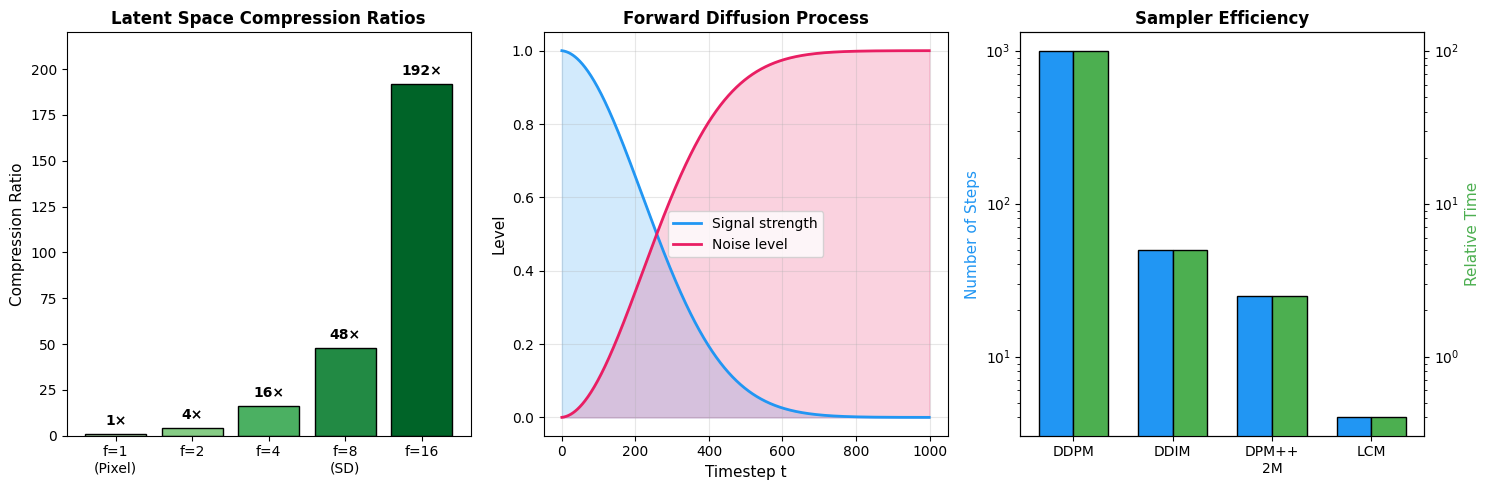


圖片已儲存為 latent_diffusion_analysis.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 圖 1：壓縮率比較
ax1 = axes[0]
factors = ['f=1\n(Pixel)', 'f=2', 'f=4', 'f=8\n(SD)', 'f=16']
dimensions = [512*512*3, 256*256*3, 128*128*3, 64*64*4, 32*32*4]
compressions = [1, 4, 16, 48, 192]

colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(factors)))
bars = ax1.bar(factors, compressions, color=colors, edgecolor='black', linewidth=1)

for bar, comp in zip(bars, compressions):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{comp}×', ha='center', fontsize=10, fontweight='bold')

ax1.set_ylabel('Compression Ratio', fontsize=11)
ax1.set_title('Latent Space Compression Ratios', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 220)

# 圖 2：擴散過程視覺化
ax2 = axes[1]
timesteps = np.arange(0, 1000, 50)
beta_start, beta_end = 0.0001, 0.02
betas = np.linspace(beta_start, beta_end, 1000)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

ax2.plot(np.arange(1000), alpha_bars, color='#2196F3', linewidth=2, label='Signal strength')
ax2.plot(np.arange(1000), 1 - alpha_bars, color='#E91E63', linewidth=2, label='Noise level')
ax2.fill_between(np.arange(1000), alpha_bars, alpha=0.2, color='#2196F3')
ax2.fill_between(np.arange(1000), 1 - alpha_bars, alpha=0.2, color='#E91E63')

ax2.set_xlabel('Timestep t', fontsize=11)
ax2.set_ylabel('Level', fontsize=11)
ax2.set_title('Forward Diffusion Process', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 圖 3：採樣步數比較
ax3 = axes[2]
samplers = ['DDPM', 'DDIM', 'DPM++\n2M', 'LCM']
steps = [1000, 50, 25, 4]
times = [100, 5, 2.5, 0.4]  # 相對時間

x = np.arange(len(samplers))
width = 0.35

bars1 = ax3.bar(x - width/2, steps, width, label='Steps', color='#2196F3', edgecolor='black')
ax3_twin = ax3.twinx()
bars2 = ax3_twin.bar(x + width/2, times, width, label='Time (rel.)', color='#4CAF50', edgecolor='black')

ax3.set_ylabel('Number of Steps', fontsize=11, color='#2196F3')
ax3_twin.set_ylabel('Relative Time', fontsize=11, color='#4CAF50')
ax3.set_title('Sampler Efficiency', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(samplers)
ax3.set_yscale('log')
ax3_twin.set_yscale('log')

plt.tight_layout()
plt.savefig('latent_diffusion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n圖片已儲存為 latent_diffusion_analysis.png")

## 10. 總結

本 notebook 實作了 Latent Diffusion Model (Stable Diffusion) 的核心組件：

1. **VAE 感知壓縮**：
   - 編碼器：圖像 → 潛在分布
   - 解碼器：潛在表示 → 圖像
   - 壓縮率約 48×（f=8）

2. **跨注意力機制**：
   - 讓圖像特徵注意到文字條件
   - Q 來自圖像，K/V 來自文字
   - 實現靈活的條件生成

3. **時間嵌入**：
   - 正弦位置編碼表示時間步
   - 通過 MLP 投影
   - 注入到 U-Net 各層

4. **Classifier-Free Guidance**：
   - 結合有條件和無條件預測
   - guidance_scale 控制條件影響力
   - 典型值為 7-12

5. **採樣方法**：
   - DDPM：原始方法，1000 步
   - DDIM：確定性採樣，50 步
   - DPM++/LCM：更快的採樣器

### 實際使用建議

對於實際的圖像生成，建議使用：
- **HuggingFace Diffusers**：官方 Python 函式庫
- **Automatic1111 WebUI**：圖形介面
- **ComfyUI**：節點式工作流

這些工具已經整合了完整的 Stable Diffusion 實作，包括各種優化和擴展功能。